# Лабораторная работа: Предварительная обработка данных

## Цель лабораторной работы
Изучение способов предварительной обработки данных для дальнейшего формирования моделей.

## Задание
Выбрать набор данных (датасет), содержащий категориальные признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.).
Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:
1. Обработка пропусков в данных.
2. Кодирование категориальных признаков.
3. Масштабирование данных.

## Требования к отчету
Отчет по лабораторной работе должен содержать:
1. Титульный лист (не включается в данный ipynb).
2. Описание задания.
3. Текст программы.
4. Экранные формы с примерами выполнения программы (в виде графиков и вывода данных).

## Импорт необходимых библиотек
Перед началом работы импортируем все необходимые библиотеки. Если какой-либо библиотеки нет, она будет установлена с помощью `!pip`.

In [39]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


## Выбор и загрузка датасета
Для данной лабораторной работы мы будем использовать датасет "Titanic: Machine Learning from Disaster" с Kaggle, так как он содержит как пропуски, так и категориальные признаки.

Мы загрузим его напрямую из GitHub репозитория, где он часто доступен в виде `csv` файла.

In [40]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
response = requests.get(url)
titanic_df = pd.read_csv(io.StringIO(response.text))

print("Первые 5 строк датасета:")
print(titanic_df.head())

print("\nИнформация о датасете:")
print(titanic_df.info())

print("\nКоличество пропущенных значений в каждом столбце:")
print(titanic_df.isnull().sum())

Первые 5 строк датасета:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

## 1. Обработка пропусков в данных
Из вывода `titanic_df.info()` и `titanic_df.isnull().sum()` видно, что пропуски присутствуют в столбцах `Age`, `Cabin` и `Embarked`.

### Стратегии обработки пропусков:
* **`Age` (возраст):** Числовой признак. Заполним пропуски медианой, так как она менее чувствительна к выбросам, чем среднее.
* **`Cabin` (номер каюты):** Содержит очень много пропусков (более 77%). В большинстве случаев такой признак лучше удалить, либо создать новую категорию 'Missing'/'Unknown'. Для целей демонстрации мы удалим его.
* **`Embarked` (порт посадки):** Категориальный признак. Заполним пропуски наиболее часто встречающимся значением (модой).

In [41]:
# Создаем копию датасета для обработки пропусков, чтобы не затрагивать исходный
df_imputed = titanic_df.copy()

# 1. Обработка 'Age': заполнение медианой
imputer_age = SimpleImputer(strategy='median')
df_imputed['Age'] = imputer_age.fit_transform(df_imputed[['Age']]).ravel()

# 2. Обработка 'Cabin': удаление столбца
df_imputed = df_imputed.drop('Cabin', axis=1)

# 3. Обработка 'Embarked': заполнение модой
imputer_embarked = SimpleImputer(strategy='most_frequent')
df_imputed['Embarked'] = imputer_embarked.fit_transform(df_imputed[['Embarked']]).ravel()

print("\nКоличество пропущенных значений после обработки:")
print(df_imputed.isnull().sum())

print("\nПервые 5 строк датасета после обработки пропусков (с 'Age' и 'Embarked'):")
print(df_imputed.head())


Количество пропущенных значений после обработки:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Первые 5 строк датасета после обработки пропусков (с 'Age' и 'Embarked'):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0

## 2. Кодирование категориальных признаков
В нашем датасете есть несколько категориальных признаков:
* `Sex`: бинарный категориальный признак ('male', 'female'). Можно использовать One-Hot Encoding или Label Encoding.
* `Embarked`: номинальный категориальный признак ('S', 'C', 'Q'). Необходимо использовать One-Hot Encoding.
* `Pclass`: порядковый категориальный признак (1, 2, 3), но по сути это категории, и для моделей машинного обучения его часто рассматривают как номинальный. Используем One-Hot Encoding.

Мы будем использовать `OneHotEncoder` для `Sex`, `Embarked` и `Pclass`, так как это распространенный и безопасный подход, который предотвращает ошибочную интерпретацию порядковых отношений между категориями.

In [42]:
# Создаем копию датасета для кодирования
df_encoded = df_imputed.copy()

# Определяем категориальные столбцы для One-Hot Encoding
categorical_cols = ['Sex', 'Embarked', 'Pclass']

# Создаем OneHotEncoder
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Применяем One-Hot Encoding
encoded_features = one_hot_encoder.fit_transform(df_encoded[categorical_cols])

# Получаем имена новых столбцов
encoded_feature_names = one_hot_encoder.get_feature_names_out(categorical_cols)

# Создаем DataFrame из закодированных признаков
df_encoded_features = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df_encoded.index)

# Объединяем закодированные признаки с исходным DataFrame и удаляем исходные категориальные столбцы
df_encoded = pd.concat([df_encoded.drop(categorical_cols, axis=1), df_encoded_features], axis=1)

print("\nПервые 5 строк датасета после кодирования категориальных признаков:")
print(df_encoded.head())

print("\nКоличество столбцов после кодирования:", df_encoded.shape[1])


Первые 5 строк датасета после кодирования категориальных признаков:
   PassengerId  Survived                                               Name  \
0            1         0                            Braund, Mr. Owen Harris   
1            2         1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3         1                             Heikkinen, Miss. Laina   
3            4         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5         0                           Allen, Mr. William Henry   

    Age  SibSp  Parch            Ticket     Fare  Sex_female  Sex_male  \
0  22.0      1      0         A/5 21171   7.2500         0.0       1.0   
1  38.0      1      0          PC 17599  71.2833         1.0       0.0   
2  26.0      0      0  STON/O2. 3101282   7.9250         1.0       0.0   
3  35.0      1      0            113803  53.1000         1.0       0.0   
4  35.0      0      0            373450   8.0500         0.0       1.0   

   Embarked

## 3. Масштабирование данных
Масштабирование данных необходимо для числовых признаков, чтобы привести их к общему диапазону. Это важно для многих алгоритмов машинного обучения (например, SVM, K-Means, нейронные сети), которые чувствительны к масштабу признаков.

В нашем датасете числовые признаки, которые требуют масштабирования:
* `Age`
* `Fare` (стоимость билета)
* `SibSp` (количество братьев/сестер/супругов на борту)
* `Parch` (количество родителей/детей на борту)

Мы используем `StandardScaler`, который стандартизует признаки путем удаления среднего значения и масштабирования до единичной дисперсии. Формула стандартизации: $z = (x - \mu) / \sigma$.

In [43]:
# Создаем копию датасета для масштабирования
df_scaled = df_encoded.copy()

# Определяем числовые столбцы для масштабирования (исключаем PatientId и закодированные категориальные)
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Создаем StandardScaler
scaler = StandardScaler()

# Применяем масштабирование к числовым столбцам
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

print("\nПервые 5 строк датасета после масштабирования числовых признаков:")
print(df_scaled.head())

print("\nСтатистика числовых признаков после масштабирования (среднее и стандартное отклонение):")
print(df_scaled[numeric_cols].describe())


Первые 5 строк датасета после масштабирования числовых признаков:
   PassengerId  Survived                                               Name  \
0            1         0                            Braund, Mr. Owen Harris   
1            2         1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3         1                             Heikkinen, Miss. Laina   
3            4         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5         0                           Allen, Mr. William Henry   

        Age     SibSp     Parch            Ticket      Fare  Sex_female  \
0 -0.565736  0.432793 -0.473674         A/5 21171 -0.502445         0.0   
1  0.663861  0.432793 -0.473674          PC 17599  0.786845         1.0   
2 -0.258337 -0.474545 -0.473674  STON/O2. 3101282 -0.488854         1.0   
3  0.433312  0.432793 -0.473674            113803  0.420730         1.0   
4  0.433312 -0.474545 -0.473674            373450 -0.486337         0.0   

   Sex_

## Визуализация результатов
Для наглядности, давайте посмотрим на распределения признаков до и после обработки.

### Распределение `Age` до и после обработки пропусков и масштабирования

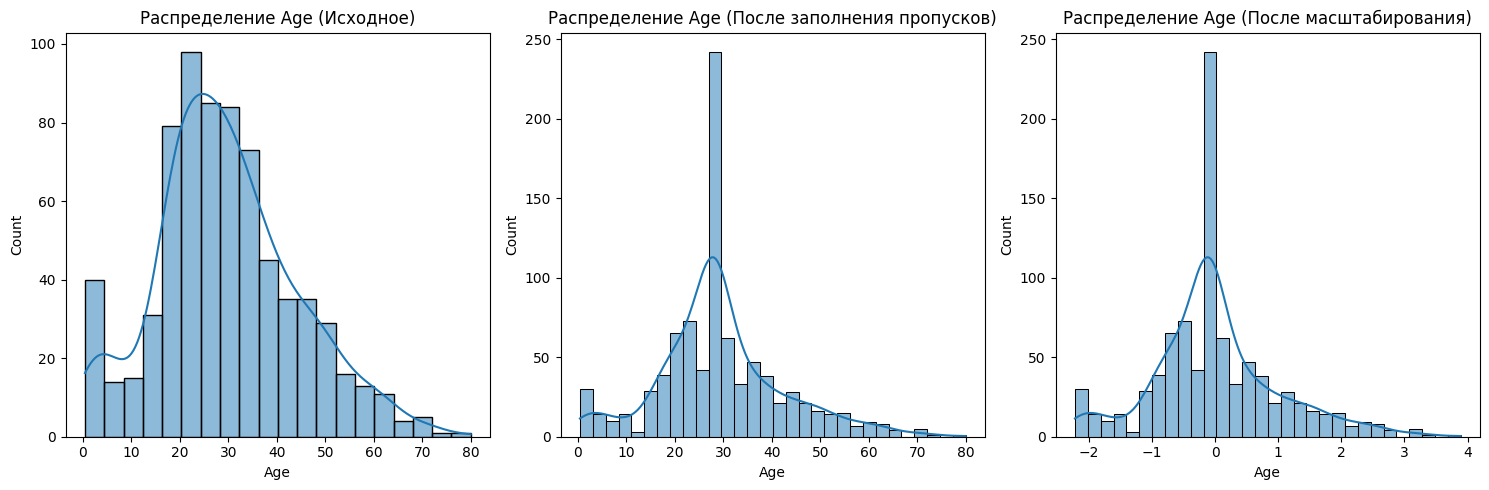

In [44]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(titanic_df['Age'].dropna(), kde=True)
plt.title('Распределение Age (Исходное)')

plt.subplot(1, 3, 2)
sns.histplot(df_imputed['Age'], kde=True)
plt.title('Распределение Age (После заполнения пропусков)')

plt.subplot(1, 3, 3)
sns.histplot(df_scaled['Age'], kde=True)
plt.title('Распределение Age (После масштабирования)')

plt.tight_layout()
plt.show()

### Распределение `Fare` до и после масштабирования

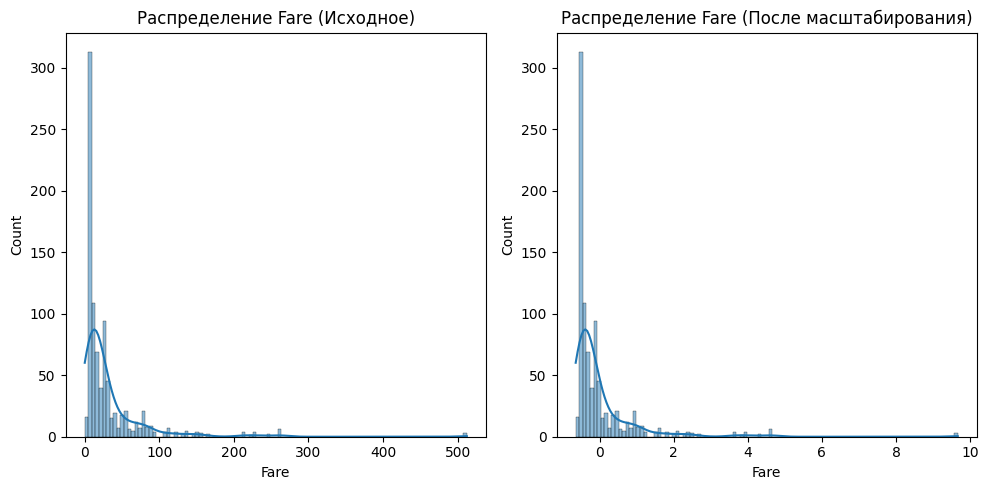

In [45]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(titanic_df['Fare'], kde=True)
plt.title('Распределение Fare (Исходное)')

plt.subplot(1, 2, 2)
sns.histplot(df_scaled['Fare'], kde=True)
plt.title('Распределение Fare (После масштабирования)')

plt.tight_layout()
plt.show()

### Визуализация закодированных категориальных признаков
Поскольку One-Hot Encoding создает новые бинарные признаки, напрямую визуализировать распределение может быть сложно. Вместо этого мы можем посмотреть на количество уникальных значений или первые строки, чтобы убедиться в правильности кодирования.

In [46]:
print("\nУникальные значения в столбце 'Sex' до кодирования:", titanic_df['Sex'].unique())
print("Уникальные значения в столбце 'Embarked' до кодирования:", titanic_df['Embarked'].unique())
print("Уникальные значения в столбце 'Pclass' до кодирования:", titanic_df['Pclass'].unique())

print("\nЗакодированные столбцы 'Sex', 'Embarked', 'Pclass' (первые 5 строк):")
print(df_scaled[['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3']].head())


Уникальные значения в столбце 'Sex' до кодирования: ['male' 'female']
Уникальные значения в столбце 'Embarked' до кодирования: ['S' 'C' 'Q' nan]
Уникальные значения в столбце 'Pclass' до кодирования: [3 1 2]

Закодированные столбцы 'Sex', 'Embarked', 'Pclass' (первые 5 строк):
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Pclass_1  \
0         0.0       1.0         0.0         0.0         1.0       0.0   
1         1.0       0.0         1.0         0.0         0.0       1.0   
2         1.0       0.0         0.0         0.0         1.0       0.0   
3         1.0       0.0         0.0         0.0         1.0       1.0   
4         0.0       1.0         0.0         0.0         1.0       0.0   

   Pclass_2  Pclass_3  
0       0.0       1.0  
1       0.0       0.0  
2       0.0       1.0  
3       0.0       0.0  
4       0.0       1.0  


## Заключение
В ходе данной лабораторной работы были выполнены следующие шаги по предварительной обработке данных:

1.  **Обработка пропусков:**
    * Пропуски в столбце `Age` были заполнены медианным значением.
    * Столбец `Cabin` был удален из-за большого количества пропусков.
    * Пропуски в столбце `Embarked` были заполнены модальным значением.

2.  **Кодирование категориальных признаков:**
    * Категориальные признаки `Sex`, `Embarked` и `Pclass` были преобразованы в числовой формат с помощью One-Hot Encoding.

3.  **Масштабирование данных:**
    * Числовые признаки `Age`, `Fare`, `SibSp` и `Parch` были стандартизированы с использованием `StandardScaler`.

Все эти шаги являются важной частью пайплайна машинного обучения и подготавливают данные для дальнейшего построения моделей, улучшая их производительность и стабильность.